In [2]:
import pandas as pd
import numpy as np

FILE_1 = "data_refined.csv"      #breast cancer data was processed as part of an introduction module
FILE_2 = "insurance_refined.csv" #insurance data was already processed as part of a regression module

df_1 = pd.read_csv(FILE_1)
df_2 = pd.read_csv(FILE_2)

print(df_1.head(5))
print(df_2.head(5))

print(df_1.shape)
print(df_2.shape)

   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0     1.097064     -2.073335        1.269934   0.984375         1.568466   
1     1.829821     -0.353632        1.685955   1.908708        -0.826962   
2     1.579888      0.456187        1.566503   1.558884         0.942210   
3    -0.768909      0.253732       -0.592687  -0.764464         3.283553   
4     1.750297     -1.151816        1.776573   1.826229         0.280372   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0          3.283515        2.652874             2.532475       2.217515   
1         -0.487072       -0.023846             0.548144       0.001392   
2          1.052926        1.363478             2.037231       0.939685   
3          3.402909        1.915897             1.451707       2.867383   
4          0.539340        1.371011             1.428493      -0.009560   

   fractal_dimension_mean  ...  texture_worst  perimeter_worst  area_worst  \
0             

Text(0, 0.5, 'Inertia')

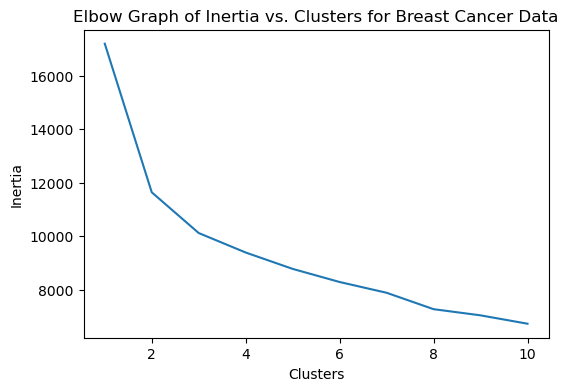

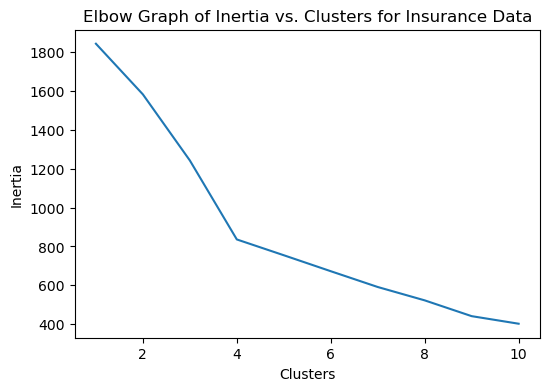

In [3]:
from sklearn.cluster import KMeans

inertia_1 = {}
inertia_2 = {}

for k in range(1,11):
    model_1 = KMeans(n_clusters=k, random_state=0).fit(df_1)
    model_2 = KMeans(n_clusters=k, random_state=0).fit(df_2)
    inertia_1[k] = model_1.inertia_
    inertia_2[k] = model_2.inertia_

import matplotlib.pyplot as plt
plt.subplots(figsize=(6, 4))
plt.plot(inertia_1.keys(), inertia_1.values())
plt.title('Elbow Graph of Inertia vs. Clusters for Breast Cancer Data')
plt.xlabel('Clusters')
plt.ylabel('Inertia')


plt.subplots(figsize=(6, 4))
plt.plot(inertia_2.keys(), inertia_2.values())
plt.title('Elbow Graph of Inertia vs. Clusters for Insurance Data')
plt.xlabel('Clusters')
plt.ylabel('Inertia')

Text(0, 0.5, 'Num Clusters')

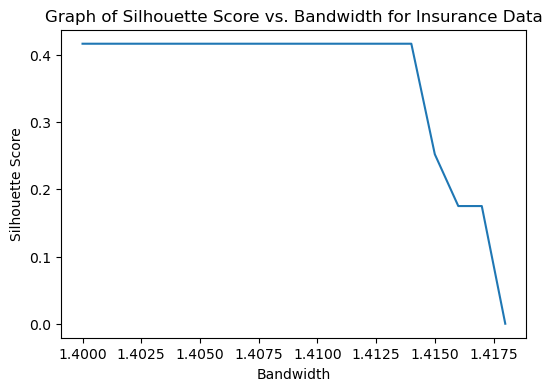

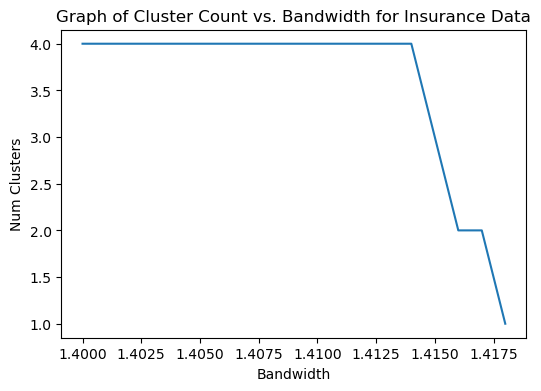

In [ ]:
from sklearn.cluster import MeanShift
from sklearn.metrics import silhouette_score

silhouette_scores_2 = {}
cluster_counts_2 = {}

b = 1.4
while b <= 1.418:
    model_2 = MeanShift(bandwidth=b).fit(df_2)
    try:
        silhouette_scores_2[b] = silhouette_score(df_2, model_2.labels_)
    except:
         silhouette_scores_2[b] = 0
    cluster_counts_2[b] = len(set(model_2.labels_))
    b+=0.001

plt.subplots(figsize=(6, 4))
plt.plot(silhouette_scores_2.keys(), silhouette_scores_2.values())
plt.title('Graph of Silhouette Score vs. Bandwidth for Insurance Data')
plt.xlabel('Bandwidth')
plt.ylabel('Silhouette Score')

plt.subplots(figsize=(6, 4))
plt.plot(cluster_counts_2.keys(), cluster_counts_2.values())
plt.title('Graph of Cluster Count vs. Bandwidth for Insurance Data')
plt.xlabel('Bandwidth')
plt.ylabel('Num Clusters')

# From the plots, we can see that a bandwidth of about 1.4 gives us a good silhouette score
# corresponding to 4 clusters in the insurance data. This is very consistent with the elbow
# graph for KMeans, which also indicates 4 clusters.

Text(0, 0.5, 'Num Clusters')

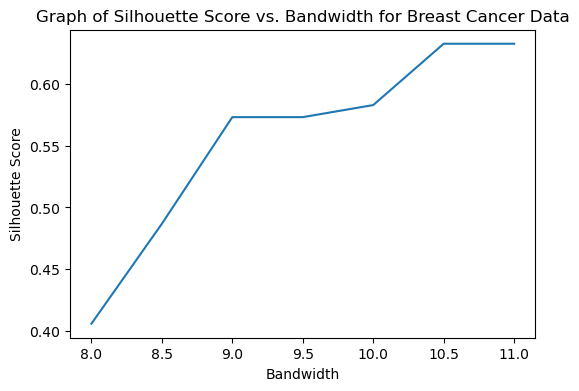

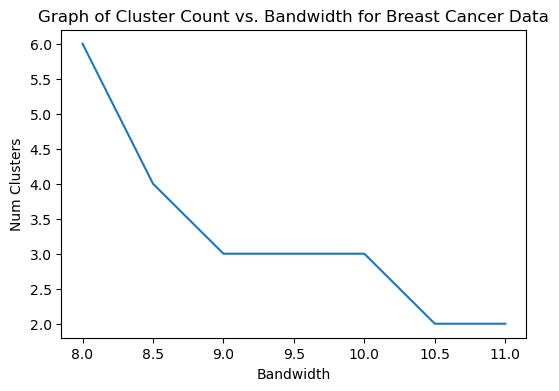

In [ ]:
silhouette_scores_1 = {}
cluster_counts_1 = {}
b = 8
while b <= 11:
    model_1 = MeanShift(bandwidth=b).fit(df_1)
    try:
        silhouette_scores_1[b] = silhouette_score(df_1, model_1.labels_)
    except:
         silhouette_scores_1[b] = 0
    cluster_counts_1[b] = len(set(model_1.labels_))
    b+=0.5

plt.subplots(figsize=(6, 4))
plt.plot(silhouette_scores_1.keys(), silhouette_scores_1.values())
plt.title('Graph of Silhouette Score vs. Bandwidth for Breast Cancer Data')
plt.xlabel('Bandwidth')
plt.ylabel('Silhouette Score')


plt.subplots(figsize=(6, 4))
plt.plot(cluster_counts_1.keys(), cluster_counts_1.values())
plt.title('Graph of Cluster Count vs. Bandwidth for Breast Cancer Data')
plt.xlabel('Bandwidth')
plt.ylabel('Num Clusters')

# From the plots, we see that we get the best silhouette score with a
# bandwidth of about 11, corresponding to 2 clusters in the breast cancer
# data. This is consistent with what we saw in the elbow graph for KMeans.

Text(0, 0.5, 'Num Clusters')

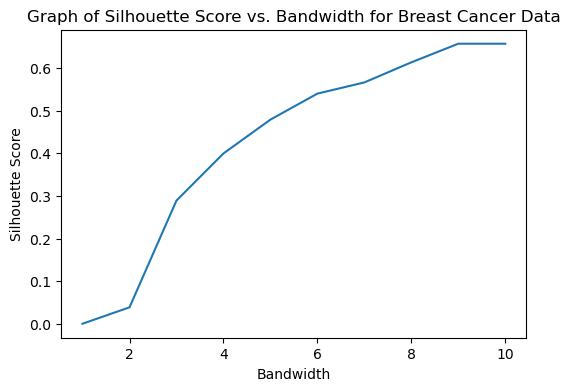

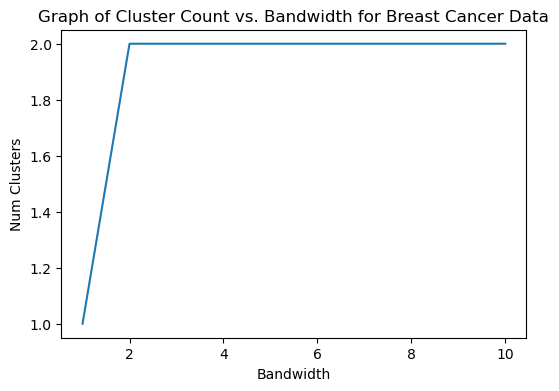

In [ ]:
from sklearn.cluster import DBSCAN

silhouette_scores_1 = {}
cluster_counts_1 = {}
eps = 1
while eps <= 10:
    model_1 = DBSCAN(eps=eps, min_samples=10).fit(df_1)
    try:
        silhouette_scores_1[eps] = silhouette_score(df_1, model_1.labels_)
    except:
         silhouette_scores_1[eps] = 0
    cluster_counts_1[eps] = len(set(model_1.labels_))
    eps+=1

plt.subplots(figsize=(6, 4))
plt.plot(silhouette_scores_1.keys(), silhouette_scores_1.values())
plt.title('Graph of Silhouette Score vs. Bandwidth for Breast Cancer Data')
plt.xlabel('Bandwidth')
plt.ylabel('Silhouette Score')


plt.subplots(figsize=(6, 4))
plt.plot(cluster_counts_1.keys(), cluster_counts_1.values())
plt.title('Graph of Cluster Count vs. Bandwidth for Breast Cancer Data')
plt.xlabel('Bandwidth')
plt.ylabel('Num Clusters')

# From the plots, we get a max silhouette score with an epsilon vale of 9
# corresponding to 2 clusters in the Breast Cancer data

Text(0, 0.5, 'Num Clusters')

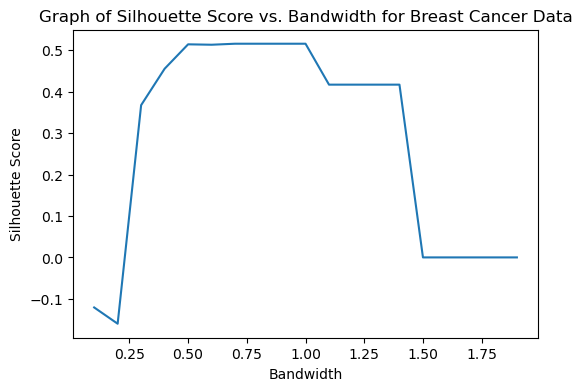

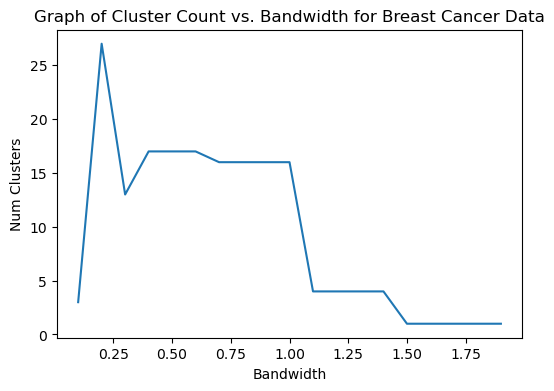

In [ ]:
silhouette_scores_2 = {}
cluster_counts_2 = {}
eps = 0.1
while eps <= 2:
    model_2 = DBSCAN(eps=eps, min_samples=10).fit(df_2)
    try:
        silhouette_scores_2[eps] = silhouette_score(df_2, model_2.labels_)
    except:
         silhouette_scores_2[eps] = 0
    cluster_counts_2[eps] = len(set(model_2.labels_))
    eps+=0.1

plt.subplots(figsize=(6, 4))
plt.plot(silhouette_scores_2.keys(), silhouette_scores_2.values())
plt.title('Graph of Silhouette Score vs. Bandwidth for Breast Cancer Data')
plt.xlabel('Bandwidth')
plt.ylabel('Silhouette Score')


plt.subplots(figsize=(6, 4))
plt.plot(cluster_counts_2.keys(), cluster_counts_2.values())
plt.title('Graph of Cluster Count vs. Bandwidth for Breast Cancer Data')
plt.xlabel('Bandwidth')
plt.ylabel('Num Clusters')

# From the plots, we get a less clear result. The best silhouette score
# corresponds to around 16 clusters while 4 clusters (which is what we
# expected from before) gives a very slightly less good score (although
# not a bad score, overall) DBSCAN might be finding more clusters than
# originally expected in the insurance data.